# Populist Governance & Physical Violence Against Journalists (A Zero-Inflated Negative Binomial Modelling Pipeline)

This notebook models the count of **physical incidents** against journalists across European countries (2015–2025) using a series of Zero-Inflated Negative Binomial (ZINB) regression models.

**Research Question:** To what extent does populist governance predict physical violence against journalists in Europe, and is this relationship conditioned by the degree of media capture in the country?


**Research Question components** 1) To what extent does populist governance predict physical violence against journalists in Europe? 2) Is this relationship conditioned by media capture (proxied by the inverted RSF press freedom score)?

**Data Sources**

| Dataset | Variable(s) | Source |
|---|---|---|
| Mapping Media Freedom (MMF) | Incident counts (physical) | ECPMF |
| V-Dem v16 | Judicial independence, media corruption, civil liberties | V-Dem Institute |
| World Bank | Military expenditure (% of GDP) | World Bank API |
| Our World in Data | Gini coefficient, mean income, relative poverty | OWID |
| PopuList 3.0 + ParlGov | Weighted populism score | Meijers & Zaslove / ParlGov |
| RSF Press Freedom Index | Press freedom score (inverted → media capture) | Reporters Without Borders |


**Outcome variable:** `physical_incidents` — count of physical assaults, injuries, deaths, abductions, arsons, sexual assaults, etc. per country-year.

**Model family:** Zero-Inflated Negative Binomial (ZINB), appropriate because incident counts are overdispersed (variance >> mean) and contain excess structural zeros.

---
# Data cleaning & merging

In [ ]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

from scipy.stats import chi2
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')



## Mapping Media Freedom (MMF) — Outcome Variable

Incidents are classified into **verbal** (intimidation, harassment, defamation, death threats) and **physical** (assault, injury, death, abduction, sexual assault, bombing) categories, then aggregated to country-year level. Filtered to 2015 onwards to align with other data sources.

In [61]:
PHYSICAL = {
    "Physical assault",
    "Injury (physical assault resulting in injury)",
    "Without injury (physical assault not resulting in injury)",
    "Death (physical assault resulting in death)",
    "Bombs / shelling / explosion / arson",
    "Abduction/kidnapping", "Sexual assault",
}

df_mmf = pd.read_csv("DATA/MMF/mapmf_alerts_cleaned-1.csv")
df_mmf["is_physical"] = df_mmf["primary_incident_type"].isin(PHYSICAL).astype(int)

df_mmf["physical_male"]   = df_mmf["is_physical"] * df_mmf["gender_male_count"].fillna(0)
df_mmf["physical_female"] = df_mmf["is_physical"] * df_mmf["gender_female_count"].fillna(0)

mmf_merged = (
    df_mmf.groupby(["country", "year"])
    .agg(
        physical_incidents=("is_physical", "sum"),
        physical_incidents_male=("physical_male", "sum"),
        physical_incidents_female=("physical_female", "sum"),
    )
    .reset_index()
)
mmf_merged = mmf_merged[mmf_merged["year"] >= 2015].copy()
mmf_merged

,country,year,physical_incidents,physical_incidents_male,physical_incidents_female
1,Albania,2015,0,0,0
2,Albania,2016,2,2,0
3,Albania,2017,3,3,1
4,Albania,2018,2,1,0
5,Albania,2019,1,1,0
...,...,...,...,...,...
451,United Kingdom,2019,2,1,1
452,United Kingdom,2020,2,2,1
453,United Kingdom,2021,2,2,0
454,United Kingdom,2022,0,0,0


## Economic Controls

Three economic variables are merged: the post-tax Gini coefficient (inequality), mean income, and the relative poverty headcount (population below 60% of median income). These serve as structural controls capturing the socioeconomic context in which journalist violence occurs.

In [62]:
df_gini    = pd.read_csv('DATA/Econ_Data/gini-coefficient-after-tax.csv')
df_income  = pd.read_csv('DATA/Econ_Data/mean-income-per-year.csv')
df_poverty = pd.read_csv('DATA/Econ_Data/relative-poverty-number-of-people-below-60-of-the-median.csv')

df_econ = pd.merge(df_gini,  df_income,  on=["Country", "Year"], how="left")
df_econ = pd.merge(df_econ,  df_poverty, on=["Country", "Year"], how="left")
df_econ

,Country,Year,Gini coefficient (after tax),Mean income per year,Number below 60% of median
0,Albania,1990,0.4296,NaN,NaN
1,Albania,1991,0.4306,NaN,NaN
2,Albania,1992,0.4333,NaN,NaN
3,Albania,1993,0.4382,NaN,NaN
4,Albania,1994,0.4410,NaN,NaN
...,...,...,...,...,...
1564,United Kingdom,2020,0.2992,23360.2336,13165017.0
1565,United Kingdom,2021,0.3070,23476.9825,12540453.0
1566,United Kingdom,2022,0.3135,NaN,NaN
1567,United Kingdom,2023,0.3075,NaN,NaN


## Military Expenditure (World Bank)
Governments that invest in military instead of healthcare or education programs can therefore lead to increased effort for citizens to get out of the poverty cycle or recover from conflict, ultimately leading to an unstable relationship between the government and its citizens. D'Agostino, Dunne, and Pieroni (2012) further show that the interaction of military spending with corruption produces particularly damaging outcomes: resources are misallocated, public trust in institutions decreases, and the effects of institutional dysfunction spread to police and judicial systems. This matters for journalist safety because, as Brambila (2017) finds, violent deaths of journalists are disproportionately concentrated in areas with high levels of social violence, human rights violations, and weak democratic development.

In [63]:
df_military = pd.read_csv(
    'DATA/military_data/API_MS.MIL.XPND.GD.ZS_DS2_en_csv_v2_16.csv', skiprows=4
)
year_cols = [c for c in df_military.columns if str(c).isdigit()]
api_long  = df_military.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols, var_name="Year", value_name="Military expenditure (% of GDP)",
)
api_long["Year"] = api_long["Year"].astype(int)
api_clean = api_long[["Country Name", "Year", "Military expenditure (% of GDP)"]].copy()
api_clean.rename(columns={"Country Name": "Country"}, inplace=True)

merged = pd.merge(df_econ, api_clean, on=["Country", "Year"], how="left")
merged

,Country,Year,Gini coefficient (after tax),Mean income per year,Number below 60% of median,Military expenditure (% of GDP)
0,Albania,1990,0.4296,NaN,NaN,5.888301
1,Albania,1991,0.4306,NaN,NaN,5.791270
2,Albania,1992,0.4333,NaN,NaN,4.670888
3,Albania,1993,0.4382,NaN,NaN,3.199451
4,Albania,1994,0.4410,NaN,NaN,2.547819
...,...,...,...,...,...,...
1564,United Kingdom,2020,0.2992,23360.2336,13165017.0,2.163040
1565,United Kingdom,2021,0.3070,23476.9825,12540453.0,2.072417
1566,United Kingdom,2022,0.3135,NaN,NaN,2.056919
1567,United Kingdom,2023,0.3075,NaN,NaN,2.230640


## V-Dem Democratic Indicators

From V-Dem v16 we extract indicators capturing the health of democratic institutions — court independence, media corruption, and civil liberty unevenness — which shape the structural risk environment for journalists.

| Variable | V-Dem code | Expected direction |
|---|---|---|
| Government attacks on judiciary | v2jupoatck | Higher = more attacks → more risk |
| High / Lower court independence | v2juhcind / v2juncind | Higher = more independent → less risk |
| Media corruption | v2mecorrpt | Higher = less corrupt → less risk |
| Educational equality | v2peedueq | Higher = more equal |
| Power by social group / gender / orientation | v2pepwrses / v2pepwrgen / v2pepwrort | Higher = more equal |
| Social class equality in civil liberty | v2clacjust | Higher = more equal |
| Subnational civil liberties unevenness | v2clrgunev | Higher = more uneven |

In [ ]:
df_vdem = pd.read_csv('DATA/V-Dem-CD-v16_csv/V-Dem-CD-v16.csv.zip',compression='zip')

In [ ]:
# Keep only relevant columns and filter for years >= 2000
df_vdem = df_vdem[df_vdem['year'] >= 2000]

# Rename columns for clarity
df_vdem = df_vdem[["country_name", "year", "v2pepwrses", "v2peedueq", "v2jupoatck", "v2juhcind", "v2juncind", "v2clacjust", "v2clrgunev", "v2mecorrpt", "v2pepwrgen", "v2pepwrort"]]
df_vdem.rename(columns={"country_name": "Country", 
                        "year": "Year",
                        "v2pepwrses": "Power distributed by social group",
                        "v2peedueq": "Educational equality",
                        "v2jupoatck": "Government attacks on judiciary",
                        "v2juhcind": "High court independence",
                        "v2juncind": "Lower court independence",
                        "v2clacjust": "Social class equality in respect for civil liberty ",
                        "v2clrgunev": "Subnational civil liberties unevenness",
                        "v2mecorrpt": "Media corruption",
                        "v2pepwrgen": "Power distributed by gender",
                        "v2pepwrort": "Power distributed by sexual orientation"
                        }, inplace=True)

df_vdem

,Country,Year,Power distributed by social group,Educational equality,Government attacks on judiciary,High court independence,Lower court independence,Social class equality in respect for civil liberty,Subnational civil liberties unevenness,Media corruption,Power distributed by gender,Power distributed by sexual orientation
633,Mexico,2000,0.109,-1.091,1.890,0.972,0.378,0.211,-1.629,0.239,0.278,-0.689
634,Mexico,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
635,Mexico,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
636,Mexico,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
637,Mexico,2000,0.109,-1.091,1.890,0.972,0.378,0.211,-1.629,0.239,0.278,-0.689
...,...,...,...,...,...,...,...,...,...,...,...,...
75491,Zanzibar,2024,0.845,1.303,2.323,0.398,0.484,0.777,0.223,0.517,0.894,-1.726
75492,Zanzibar,2025,0.845,1.051,2.323,0.398,0.484,0.638,0.223,0.517,0.964,-1.337
75493,Zanzibar,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75494,Zanzibar,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_vdem = df_vdem.groupby(["Country", "Year"])[
    ["Power distributed by social group",
     "Educational equality",
     "Government attacks on judiciary",
     "High court independence",
     "Lower court independence",
     "Social class equality in respect for civil liberty ",
     "Subnational civil liberties unevenness",
     "Media corruption", "Power distributed by gender", "Power distributed by sexual orientation"]
].mean().reset_index()

In [ ]:
merged = pd.merge(
    merged,
    df_vdem,
    on=["Country", "Year"],
    how="left",        
)
merged

,Country,Year,Gini coefficient (after tax),Mean income per year,Number below 60% of median,Military expenditure (% of GDP),Power distributed by social group,Educational equality,Government attacks on judiciary,High court independence,Lower court independence,Social class equality in respect for civil liberty,Subnational civil liberties unevenness,Media corruption,Power distributed by gender,Power distributed by sexual orientation
0,Albania,1990,0.4296,NaN,NaN,5.888301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,1991,0.4306,NaN,NaN,5.791270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,1992,0.4333,NaN,NaN,4.670888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,1993,0.4382,NaN,NaN,3.199451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Albania,1994,0.4410,NaN,NaN,2.547819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1564,United Kingdom,2020,0.2992,23360.2336,13165017.0,2.163040,0.732,1.578,1.100,2.18,1.97,1.884,2.096,2.42,2.002,2.399
1565,United Kingdom,2021,0.3070,23476.9825,12540453.0,2.072417,0.732,1.907,0.754,2.18,1.97,1.484,1.332,2.42,2.002,2.148
1566,United Kingdom,2022,0.3135,NaN,NaN,2.056919,0.732,1.523,0.754,2.18,1.97,1.812,1.332,2.42,2.002,2.148
1567,United Kingdom,2023,0.3075,NaN,NaN,2.230640,0.732,1.523,0.793,2.18,1.97,1.812,1.332,2.42,2.002,2.260


## RSF Press Freedom Index — Media Capture Proxy

The RSF index scores press freedom 0 (worst) to 100 (best). 

**Harmonisation note:** RSF changed its methodology in 2022. For 2018–2021 the pre-built composite score (excluding the Safety/exactions component) is used. For 2022–2025 the four structural sub-components (Political, Economic, Legal, Social context) are averaged, again excluding Safety, to ensure comparability across the full panel.

In [ ]:
df_media_freedom_2018 = pd.read_csv('DATA/RSF/2018.csv', sep=";")
df_media_freedom_2019 = pd.read_csv('DATA/RSF/2019.csv', sep=";")
df_media_freedom_2020 = pd.read_csv('DATA/RSF/2020.csv', sep=";")
df_media_freedom_2021 = pd.read_csv('DATA/RSF/2021.csv', sep=";")
df_media_freedom_2022 = pd.read_csv('DATA/RSF/2022.csv', sep=";")
df_media_freedom_2023 = pd.read_csv('DATA/RSF/2023.csv', sep=";")
df_media_freedom_2024 = pd.read_csv('DATA/RSF/2024.csv', sep=";")
df_media_freedom_2025 = pd.read_csv('DATA/RSF/2025.csv', sep=";", encoding='latin1')


In [ ]:
_SUBCOMPS = ["Political Context", "Economic Context", "Legal Context", "Social Context"]

# 2018-2021: use the pre-built "without exactions" score (excludes Safety/violence component)
df_media_freedom_2018 = df_media_freedom_2018[["EN_country", "Year (N)", "Score N without the exactions"]]
df_media_freedom_2019 = df_media_freedom_2019[["EN_country", "Year (N)", "Score N without the exactions"]]
df_media_freedom_2020 = df_media_freedom_2020[["EN_country", "Year (N)", "Score N without the exactions"]]
df_media_freedom_2021 = df_media_freedom_2021[["EN_country", "Year (N)", "Score N without the exactions"]]

# 2022-2025: keep the 4 sub-components (Safety excluded)
df_media_freedom_2022 = df_media_freedom_2022[["Country_EN", "Year (N)"] + _SUBCOMPS]
df_media_freedom_2023 = df_media_freedom_2023[["Country_EN", "Year (N)"] + _SUBCOMPS]
df_media_freedom_2024 = df_media_freedom_2024[["Country_EN", "Year (N)"] + _SUBCOMPS]
df_media_freedom_2025 = df_media_freedom_2025[["Country_EN", "Year (N)"] + _SUBCOMPS]


In [ ]:
# 2018-2021: rename directly
for _df in [df_media_freedom_2018, df_media_freedom_2019, df_media_freedom_2020, df_media_freedom_2021]:
    _df.rename(columns={"EN_country": "Country", "Year (N)": "Year",
                         "Score N without the exactions": "rsf_score"}, inplace=True)

# 2022-2025: convert sub-components from European decimal, compute mean of 4 (Safety excluded)
for _df in [df_media_freedom_2022, df_media_freedom_2023, df_media_freedom_2024, df_media_freedom_2025]:
    for _col in _SUBCOMPS:
        _df[_col] = pd.to_numeric(_df[_col].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    _df["rsf_score"] = _df[_SUBCOMPS].mean(axis=1)
    _df.drop(columns=_SUBCOMPS, inplace=True)
    _df.rename(columns={"Country_EN": "Country", "Year (N)": "Year"}, inplace=True)


In [ ]:
df_media_freedom = pd.concat([
    df_media_freedom_2018,
    df_media_freedom_2019,
    df_media_freedom_2020,
    df_media_freedom_2021,
    df_media_freedom_2022,
    df_media_freedom_2023,
    df_media_freedom_2024,
    df_media_freedom_2025
], ignore_index=True)

df_media_freedom["rsf_score"] = (
    df_media_freedom["rsf_score"].astype(str).str.replace(",", ".", regex=False)
)
df_media_freedom["rsf_score"] = pd.to_numeric(df_media_freedom["rsf_score"], errors="coerce")

df_media_freedom

,Country,Year,rsf_score
0,Norway,2018,92.3700
1,Sweden,2018,91.6900
2,Netherlands,2018,89.9900
3,Finland,2018,89.7400
4,Switzerland,2018,88.7300
...,...,...,...
1435,Iran,2025,15.8625
1436,Turkmenistan,2025,17.1175
1437,China,2025,14.3175
1438,North Korea,2025,12.3400


In [ ]:
merged = pd.merge(
    merged,
    df_media_freedom,
    on=["Country", "Year"],
    how="left", )       
    
merged

,Country,Year,Gini coefficient (after tax),Mean income per year,Number below 60% of median,Military expenditure (% of GDP),Power distributed by social group,Educational equality,Government attacks on judiciary,High court independence,Lower court independence,Social class equality in respect for civil liberty,Subnational civil liberties unevenness,Media corruption,Power distributed by gender,Power distributed by sexual orientation,rsf_score
0,Albania,1990,0.4296,NaN,NaN,5.888301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,1991,0.4306,NaN,NaN,5.791270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,1992,0.4333,NaN,NaN,4.670888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,1993,0.4382,NaN,NaN,3.199451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Albania,1994,0.4410,NaN,NaN,2.547819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1564,United Kingdom,2020,0.2992,23360.2336,13165017.0,2.163040,0.732,1.578,1.100,2.18,1.97,1.884,2.096,2.42,2.002,2.399,82.5900
1565,United Kingdom,2021,0.3070,23476.9825,12540453.0,2.072417,0.732,1.907,0.754,2.18,1.97,1.484,1.332,2.42,2.002,2.148,78.3500
1566,United Kingdom,2022,0.3135,NaN,NaN,2.056919,0.732,1.523,0.754,2.18,1.97,1.812,1.332,2.42,2.002,2.148,78.5600
1567,United Kingdom,2023,0.3075,NaN,NaN,2.230640,0.732,1.523,0.793,2.18,1.97,1.812,1.332,2.42,2.002,2.260,77.6100


## Weighted populism score

Populism is operationalised as the **seat-weighted share of populist parties in government**, matched from the PopuList 3.0 dataset to ParlGov cabinet data via `parlgov_id`.

$$\text{Weighted Populism}_{c,t} = \frac{\sum_{p \in \text{populist}} \text{seats}_p}{\text{total seats}}$$

Parties absent from PopuList are treated as mainstream (coded 0), making the measure for a country a continuous proportion from 0 (no populist presence) to 1 (fully populist cabinet).

In [ ]:
# PopuList: populist parties in Europe
df_populist = pd.read_csv('DATA/PopuList/The PopuList 3.0.csv', sep=";")

# ParlGov: cabinet composition and seat shares
df_cabinet  = pd.read_csv('DATA/ParlGov/view_cabinet.csv')

# ── 2. Prepare PopuList lookup via direct parlgov_id join ────────────────────
populist_lookup = (
    df_populist
    .dropna(subset=["parlgov_id"])
    [["parlgov_id", "populist", "farright", "farleft", "eurosceptic"]]
    .copy()
)
populist_lookup["parlgov_id"] = populist_lookup["parlgov_id"].astype(int)

# ── 3. Prepare cabinet data — filter to study period ─────────────────────────
df_cabinet["Year"] = pd.to_datetime(df_cabinet["start_date"]).dt.year
df_cabinet = df_cabinet[df_cabinet["Year"] >= 2015].copy()
df_cabinet = df_cabinet[
    ["country_name", "Year", "party_name", "party_id", "seats", "election_seats_total"]
].dropna(subset=["seats"])

# ── 4. Join on party_id = parlgov_id ─────────────────────────────────────────
df_cabinet = df_cabinet.merge(
    populist_lookup,
    left_on="party_id",
    right_on="parlgov_id",
    how="left",
)

# Parties absent from PopuList are mainstream → treat as 0
for col in ["populist", "farright", "farleft", "eurosceptic"]:
    df_cabinet[col] = df_cabinet[col].fillna(0).astype(int)

df_cabinet["weighted_populism"]= df_cabinet["populist"] * (df_cabinet["seats"] / df_cabinet["election_seats_total"])
df_cabinet.to_csv("DATA/weighted_populism_score.csv", index=False)

weighted_populism = df_cabinet.groupby(["country_name", "Year"])[["weighted_populism"]].sum().reset_index()
weighted_populism.rename(columns={"country_name": "Country"}, inplace=True)

weighted_populism


,Country,Year,weighted_populism
0,Australia,2015,0.000000
1,Australia,2016,0.000000
2,Australia,2018,0.000000
3,Australia,2019,0.000000
4,Australia,2022,0.000000
...,...,...,...
138,United Kingdom,2015,0.013846
139,United Kingdom,2016,0.013846
140,United Kingdom,2017,0.015385
141,United Kingdom,2019,0.027692


In [ ]:
df_cabinet.head(20)

,country_name,Year,party_name,party_id,seats,election_seats_total,parlgov_id,populist,farright,farleft,eurosceptic,weighted_populism
0,Australia,2015,Australian Greens,751,1,150,NaN,0,0,0,0,0.0
1,Australia,2015,Australian Labor Party,1253,55,150,NaN,0,0,0,0,0.0
2,Australia,2015,Country Liberal Party,215,1,150,NaN,0,0,0,0,0.0
3,Australia,2015,Katter's Australian Party,2258,1,150,NaN,0,0,0,0,0.0
4,Australia,2015,Liberal National Party of Queensland,154,22,150,NaN,0,0,0,0,0.0
5,Australia,2015,Liberal Party of Australia,1411,58,150,NaN,0,0,0,0,0.0
6,Australia,2015,National (Country) Party | National Party of A...,184,9,150,NaN,0,0,0,0,0.0
7,Australia,2015,Palmer United Australia Party,2259,1,150,NaN,0,0,0,0,0.0
8,Australia,2015,no party affiliation,1396,2,150,NaN,0,0,0,0,0.0
9,Australia,2016,Australian Greens,751,1,150,NaN,0,0,0,0,0.0


In [ ]:
merged = pd.merge(
    merged, weighted_populism, on=["Country", "Year"], how="left"
)
merged

,Country,Year,Gini coefficient (after tax),Mean income per year,Number below 60% of median,Military expenditure (% of GDP),Power distributed by social group,Educational equality,Government attacks on judiciary,High court independence,Lower court independence,Social class equality in respect for civil liberty,Subnational civil liberties unevenness,Media corruption,Power distributed by gender,Power distributed by sexual orientation,rsf_score,weighted_populism
0,Albania,1990,0.4296,NaN,NaN,5.888301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,1991,0.4306,NaN,NaN,5.791270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Albania,1992,0.4333,NaN,NaN,4.670888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,1993,0.4382,NaN,NaN,3.199451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Albania,1994,0.4410,NaN,NaN,2.547819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1564,United Kingdom,2020,0.2992,23360.2336,13165017.0,2.163040,0.732,1.578,1.100,2.18,1.97,1.884,2.096,2.42,2.002,2.399,82.5900,NaN
1565,United Kingdom,2021,0.3070,23476.9825,12540453.0,2.072417,0.732,1.907,0.754,2.18,1.97,1.484,1.332,2.42,2.002,2.148,78.3500,NaN
1566,United Kingdom,2022,0.3135,NaN,NaN,2.056919,0.732,1.523,0.754,2.18,1.97,1.812,1.332,2.42,2.002,2.148,78.5600,0.024615
1567,United Kingdom,2023,0.3075,NaN,NaN,2.230640,0.732,1.523,0.793,2.18,1.97,1.812,1.332,2.42,2.002,2.260,77.6100,NaN


## Aggregated Dataframe processing

In [ ]:
mmf_merged.rename(columns={"country": "Country", "year": "Year"}, inplace=True)

cy = pd.merge(
    mmf_merged, merged, on=["Country", "Year"], how="left"
)
cy



,Country,Year,physical_incidents,physical_incidents_male,physical_incidents_female,Gini coefficient (after tax),Mean income per year,Number below 60% of median,Military expenditure (% of GDP),Power distributed by social group,...,Government attacks on judiciary,High court independence,Lower court independence,Social class equality in respect for civil liberty,Subnational civil liberties unevenness,Media corruption,Power distributed by gender,Power distributed by sexual orientation,rsf_score,weighted_populism
0,Albania,2015,0,0,0,0.4634,NaN,540449.0,1.162304,-0.196,...,-1.640,0.521,0.764,0.916,1.872,0.066,1.401,0.530,NaN,NaN
1,Albania,2016,2,2,0,0.4785,3862.677105,577118.0,1.103581,-0.196,...,-1.786,0.521,0.764,0.916,1.872,0.066,1.401,0.530,NaN,NaN
2,Albania,2017,3,3,1,0.4651,4043.774045,550249.0,1.109151,-0.196,...,-2.226,0.644,0.764,0.916,1.872,0.083,1.401,0.530,NaN,NaN
3,Albania,2018,2,1,0,0.4589,4232.630885,534536.0,1.160545,-0.548,...,-2.226,0.644,0.764,0.916,1.872,0.045,1.401,0.893,70.51,NaN
4,Albania,2019,1,1,0,0.4477,NaN,452479.0,1.280806,-0.839,...,-1.157,0.860,0.666,0.931,1.872,0.045,1.401,0.893,70.16,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,United Kingdom,2019,2,1,1,0.3181,23475.453150,13321199.0,1.985254,0.700,...,1.017,1.928,1.970,1.884,2.096,2.452,1.925,2.069,77.77,0.027692
417,United Kingdom,2020,2,2,1,0.2992,23360.233600,13165017.0,2.163040,0.732,...,1.100,2.180,1.970,1.884,2.096,2.420,2.002,2.399,82.59,NaN
418,United Kingdom,2021,2,2,0,0.3070,23476.982500,12540453.0,2.072417,0.732,...,0.754,2.180,1.970,1.484,1.332,2.420,2.002,2.148,78.35,NaN
419,United Kingdom,2022,0,0,0,0.3135,NaN,NaN,2.056919,0.732,...,0.754,2.180,1.970,1.812,1.332,2.420,2.002,2.148,78.56,0.024615


#### One-Year Lag

All predictors are lagged one year relative to the outcome to reduce reverse causality risk and reflect the realistic delay between political conditions and observable journalist violence.## Lag

In [ ]:
cols_to_shift = cy.columns.difference(
    ["Country", "Year", "verbal_incidents", "physical_incidents",
     "physical_incidents_male", "physical_incidents_female"]
)

for col in cols_to_shift:
    cy[col] = cy.groupby("Country")[col].shift(1)

cy

,Country,Year,physical_incidents,physical_incidents_male,physical_incidents_female,Gini coefficient (after tax),Mean income per year,Number below 60% of median,Military expenditure (% of GDP),Power distributed by social group,...,Government attacks on judiciary,High court independence,Lower court independence,Social class equality in respect for civil liberty,Subnational civil liberties unevenness,Media corruption,Power distributed by gender,Power distributed by sexual orientation,rsf_score,weighted_populism
0,Albania,2015,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,2016,2,2,0,0.4634,NaN,540449.0,1.162304,-0.196,...,-1.640,0.521,0.764,0.916,1.872,0.066,1.401,0.530,NaN,NaN
2,Albania,2017,3,3,1,0.4785,3862.677105,577118.0,1.103581,-0.196,...,-1.786,0.521,0.764,0.916,1.872,0.066,1.401,0.530,NaN,NaN
3,Albania,2018,2,1,0,0.4651,4043.774045,550249.0,1.109151,-0.196,...,-2.226,0.644,0.764,0.916,1.872,0.083,1.401,0.530,NaN,NaN
4,Albania,2019,1,1,0,0.4589,4232.630885,534536.0,1.160545,-0.548,...,-2.226,0.644,0.764,0.916,1.872,0.045,1.401,0.893,70.51,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,United Kingdom,2019,2,1,1,0.3200,23159.582880,13253288.0,1.944556,0.700,...,1.348,1.928,1.970,1.884,2.096,2.452,1.925,2.274,76.75,NaN
417,United Kingdom,2020,2,2,1,0.3181,23475.453150,13321199.0,1.985254,0.700,...,1.017,1.928,1.970,1.884,2.096,2.452,1.925,2.069,77.77,0.027692
418,United Kingdom,2021,2,2,0,0.2992,23360.233600,13165017.0,2.163040,0.732,...,1.100,2.180,1.970,1.884,2.096,2.420,2.002,2.399,82.59,NaN
419,United Kingdom,2022,0,0,0,0.3070,23476.982500,12540453.0,2.072417,0.732,...,0.754,2.180,1.970,1.484,1.332,2.420,2.002,2.148,78.35,NaN


### Imputation to fill in NULL
Missing values are filled by forward-fill within each country group. Forward-fill carries the last observed value forward (appropriate for slowly-changing structural indicators).

In [ ]:
cy = (
    cy.sort_values(["Country", "Year"])
      .groupby("Country", as_index=False)
      .apply(lambda x: x.ffill())
      .reset_index(drop=True)
)

cy

,Country,Year,physical_incidents,physical_incidents_male,physical_incidents_female,Gini coefficient (after tax),Mean income per year,Number below 60% of median,Military expenditure (% of GDP),Power distributed by social group,...,Government attacks on judiciary,High court independence,Lower court independence,Social class equality in respect for civil liberty,Subnational civil liberties unevenness,Media corruption,Power distributed by gender,Power distributed by sexual orientation,rsf_score,weighted_populism
0,Albania,2015,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,2016,2,2,0,0.4634,NaN,540449.0,1.162304,-0.196,...,-1.640,0.521,0.764,0.916,1.872,0.066,1.401,0.530,NaN,NaN
2,Albania,2017,3,3,1,0.4785,3862.677105,577118.0,1.103581,-0.196,...,-1.786,0.521,0.764,0.916,1.872,0.066,1.401,0.530,NaN,NaN
3,Albania,2018,2,1,0,0.4651,4043.774045,550249.0,1.109151,-0.196,...,-2.226,0.644,0.764,0.916,1.872,0.083,1.401,0.530,NaN,NaN
4,Albania,2019,1,1,0,0.4589,4232.630885,534536.0,1.160545,-0.548,...,-2.226,0.644,0.764,0.916,1.872,0.045,1.401,0.893,70.51,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,United Kingdom,2019,2,1,1,0.3200,23159.582880,13253288.0,1.944556,0.700,...,1.348,1.928,1.970,1.884,2.096,2.452,1.925,2.274,76.75,0.015385
417,United Kingdom,2020,2,2,1,0.3181,23475.453150,13321199.0,1.985254,0.700,...,1.017,1.928,1.970,1.884,2.096,2.452,1.925,2.069,77.77,0.027692
418,United Kingdom,2021,2,2,0,0.2992,23360.233600,13165017.0,2.163040,0.732,...,1.100,2.180,1.970,1.884,2.096,2.420,2.002,2.399,82.59,0.027692
419,United Kingdom,2022,0,0,0,0.3070,23476.982500,12540453.0,2.072417,0.732,...,0.754,2.180,1.970,1.484,1.332,2.420,2.002,2.148,78.35,0.027692


Removing Russia and Ukraine as they are outliers due to the ongoing conflict.

In [ ]:
cy = cy[~cy["Country"].isin(["Russia", "Ukraine"])]
cy

,Country,Year,physical_incidents,physical_incidents_male,physical_incidents_female,Gini coefficient (after tax),Mean income per year,Number below 60% of median,Military expenditure (% of GDP),Power distributed by social group,...,Government attacks on judiciary,High court independence,Lower court independence,Social class equality in respect for civil liberty,Subnational civil liberties unevenness,Media corruption,Power distributed by gender,Power distributed by sexual orientation,rsf_score,weighted_populism
0,Albania,2015,0,0,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,2016,2,2,0,0.4634,NaN,540449.0,1.162304,-0.196,...,-1.640,0.521,0.764,0.916,1.872,0.066,1.401,0.530,NaN,NaN
2,Albania,2017,3,3,1,0.4785,3862.677105,577118.0,1.103581,-0.196,...,-1.786,0.521,0.764,0.916,1.872,0.066,1.401,0.530,NaN,NaN
3,Albania,2018,2,1,0,0.4651,4043.774045,550249.0,1.109151,-0.196,...,-2.226,0.644,0.764,0.916,1.872,0.083,1.401,0.530,NaN,NaN
4,Albania,2019,1,1,0,0.4589,4232.630885,534536.0,1.160545,-0.548,...,-2.226,0.644,0.764,0.916,1.872,0.045,1.401,0.893,70.51,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,United Kingdom,2019,2,1,1,0.3200,23159.582880,13253288.0,1.944556,0.700,...,1.348,1.928,1.970,1.884,2.096,2.452,1.925,2.274,76.75,0.015385
417,United Kingdom,2020,2,2,1,0.3181,23475.453150,13321199.0,1.985254,0.700,...,1.017,1.928,1.970,1.884,2.096,2.452,1.925,2.069,77.77,0.027692
418,United Kingdom,2021,2,2,0,0.2992,23360.233600,13165017.0,2.163040,0.732,...,1.100,2.180,1.970,1.884,2.096,2.420,2.002,2.399,82.59,0.027692
419,United Kingdom,2022,0,0,0,0.3070,23476.982500,12540453.0,2.072417,0.732,...,0.754,2.180,1.970,1.484,1.332,2.420,2.002,2.148,78.35,0.027692


In [ ]:
cy.dropna(inplace=True)
print(f"Shape after dropping NaN values: {cy.shape}\n")
print(f"Countries in the dataset included in the analysis: {cy.Country.unique()}\n")
print(f"Years in the dataset included in the analysis: {cy.Year.unique().min()} to {cy.Year.unique().max()}")

Shape after dropping NaN values: (174, 21)

Countries in the dataset included in the analysis: ['Austria' 'Belgium' 'Bulgaria' 'Croatia' 'Cyprus' 'Denmark' 'Estonia'
 'Finland' 'France' 'Germany' 'Greece' 'Hungary' 'Ireland' 'Italy'
 'Latvia' 'Lithuania' 'Luxembourg' 'Malta' 'Netherlands' 'Poland'
 'Portugal' 'Romania' 'Slovenia' 'Spain' 'Sweden' 'United Kingdom']

Years in the dataset included in the analysis: 2019 to 2026


In [ ]:
cy

,Country,Year,physical_incidents,physical_incidents_male,physical_incidents_female,Gini coefficient (after tax),Mean income per year,Number below 60% of median,Military expenditure (% of GDP),Power distributed by social group,...,Government attacks on judiciary,High court independence,Lower court independence,Social class equality in respect for civil liberty,Subnational civil liberties unevenness,Media corruption,Power distributed by gender,Power distributed by sexual orientation,rsf_score,weighted_populism
15,Austria,2019,0,0,0,0.2905,28159.253600,1551459.0,0.748993,0.929,...,0.498,2.093,1.587,2.727,2.358,2.179,1.407,1.691,85.9600,0.322404
16,Austria,2020,1,1,0,0.2863,28723.901300,1468884.0,0.753133,1.036,...,0.498,2.596,1.587,2.727,2.358,2.309,1.594,2.275,84.6700,0.491803
17,Austria,2021,0,0,0,0.2850,28798.470800,1484216.0,0.885812,1.189,...,0.487,2.596,1.587,3.284,2.358,1.354,1.755,2.275,84.2200,0.169399
18,Austria,2022,0,0,0,0.2838,28745.100500,1587973.0,0.873515,1.006,...,-0.420,2.596,2.449,3.284,2.358,1.254,1.755,1.889,83.6600,0.338798
19,Austria,2023,2,3,1,0.2862,30085.752800,1585755.0,0.766706,1.006,...,0.293,2.596,2.449,3.284,2.358,0.933,1.755,1.715,74.8500,0.338798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,Sweden,2025,0,0,0,0.2431,22934.368025,1692706.0,1.997717,1.476,...,2.326,2.889,2.855,2.305,2.355,3.256,3.388,2.074,87.3675,0.209169
416,United Kingdom,2019,2,1,1,0.3200,23159.582880,13253288.0,1.944556,0.700,...,1.348,1.928,1.970,1.884,2.096,2.452,1.925,2.274,76.7500,0.015385
417,United Kingdom,2020,2,2,1,0.3181,23475.453150,13321199.0,1.985254,0.700,...,1.017,1.928,1.970,1.884,2.096,2.452,1.925,2.069,77.7700,0.027692
418,United Kingdom,2021,2,2,0,0.2992,23360.233600,13165017.0,2.163040,0.732,...,1.100,2.180,1.970,1.884,2.096,2.420,2.002,2.399,82.5900,0.027692


In [ ]:
cy.to_csv("DATA/aggregated_data.csv", index=False)

# Exploratory Data Analysis

Before modelling, we inspect outcome distributions, time trends, and predictor–outcome correlations. These diagnostics directly inform the choice of model family.

In [ ]:
# Predictors used in the final model (raw, pre-lag values)
PRED_COLS = cy.columns.drop(["Country", "Year", "physical_incidents"]).tolist()
OUTCOME_COLS = ["physical_incidents"]


## Outcome distribution
Key diagnostics:
- **Zero share:** A high proportion of zeros (>40%) justifies the zero-inflation component of the ZINB model.
- **Overdispersion ratio (variance / mean):** A ratio >> 1 rules out standard Poisson and justifies the Negative Binomial family.

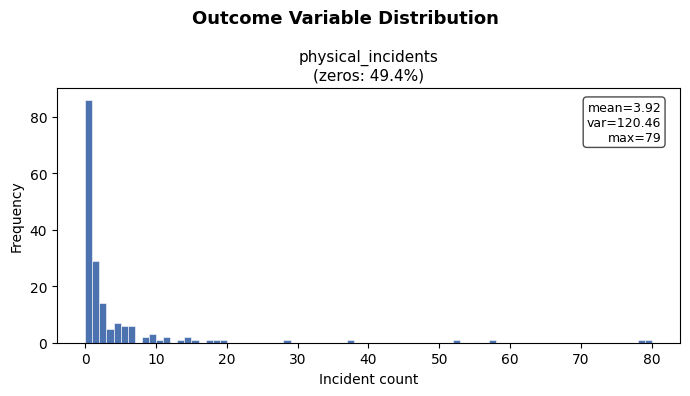

physical_incidents: mean=3.920, var=120.456, dispersion ratio=30.73


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

col    = "physical_incidents"
counts = cy[col]
zero_pct = (counts == 0).mean() * 100

ax.hist(counts, bins=range(0, int(counts.max()) + 2),
        color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.set_title(f"{col}\n(zeros: {zero_pct:.1f}%)", fontsize=11)
ax.set_xlabel("Incident count")
ax.set_ylabel("Frequency")
ax.annotate(
    f"mean={counts.mean():.2f}\nvar={counts.var():.2f}\nmax={counts.max()}",
    xy=(0.97, 0.95), xycoords="axes fraction",
    ha="right", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
)

fig.suptitle("Outcome Variable Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

m, v = counts.mean(), counts.var()
print(f"{col}: mean={m:.3f}, var={v:.3f}, dispersion ratio={v/m:.2f}")

**Interpretation:** The large zero share and dispersion ratio >> 1 confirm that ZINB is the appropriate model family. A standard Poisson would underestimate variance and produce incorrect standard errors; a plain Negative Binomial would not account for structural zeros.

## Incidents over time

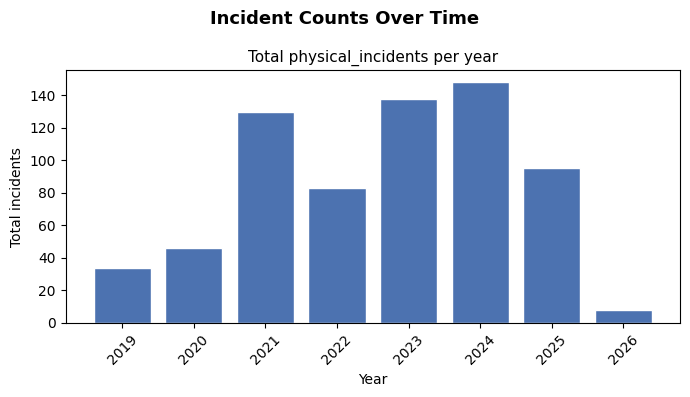

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

col    = "physical_incidents"
yearly = cy.groupby("Year")[col].sum().reset_index()

ax.bar(yearly["Year"], yearly[col], color="#4C72B0", edgecolor="white")
ax.set_title(f"Total {col} per year", fontsize=11)
ax.set_xlabel("Year")
ax.set_ylabel("Total incidents")
ax.set_xticks(yearly["Year"])
ax.tick_params(axis="x", rotation=45)

fig.suptitle("Incident Counts Over Time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** Year-on-year changes in incident totals may coincide with political events such as the election of populist governments or democratic backsliding episodes. This is one of the model's limitation.

## Geographic Distribution

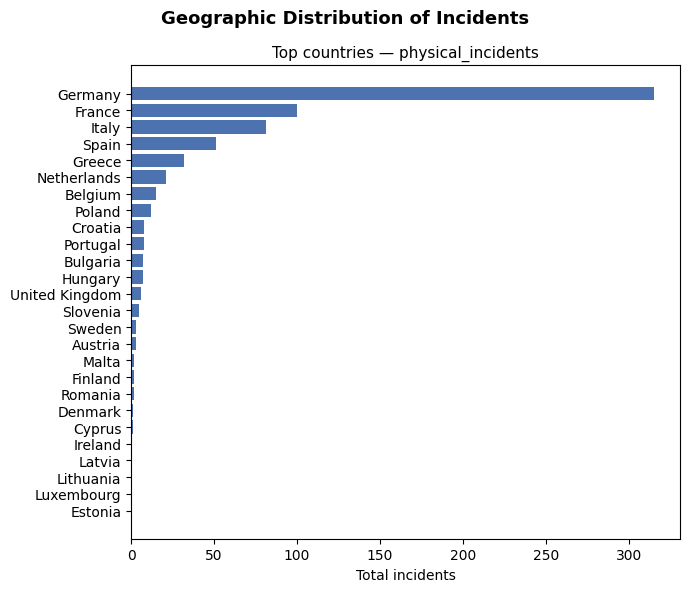

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

col = "physical_incidents"
top = (
    cy.groupby("Country")[col].sum()
    .sort_values(ascending=False)
)

ax.barh(top.index[::-1], top.values[::-1], color="#4C72B0")
ax.set_title(f"Top countries — {col}", fontsize=11)
ax.set_xlabel("Total incidents")

fig.suptitle("Geographic Distribution of Incidents", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:** Incident concentration in a few countries reflects both political risk and reporting density.

In [ ]:
results = []

for col in PRED_COLS:
    # Drop rows with missing values in either variable
    mask = cy[[col, "physical_incidents"]].notna().all(axis=1)
    if mask.sum() < 3:
        # Not enough data points to compute a correlation
        results.append((col, np.nan, np.nan, mask.sum()))
        continue

    r, p = pearsonr(cy.loc[mask, col], cy.loc[mask, "physical_incidents"])
    results.append((col, r, p, mask.sum()))

corr_df = pd.DataFrame(
    results,
    columns=["predictor", "pearson_r", "p_value", "n_obs"]
)

# Sort by absolute correlation strength
corr_df["abs_r"] = corr_df["pearson_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False).drop(columns="abs_r")

print("\nPearson correlation with physical_incidents:")
print(corr_df.to_string(index=False))


Pearson correlation with physical_incidents:
                                          predictor  pearson_r       p_value  n_obs
                            physical_incidents_male   0.992436 1.278171e-158    174
                          physical_incidents_female   0.893697  9.189014e-62    174
                         Number below 60% of median   0.570833  1.972553e-16    174
             Subnational civil liberties unevenness   0.280517  1.774247e-04    174
                               Mean income per year   0.238563  1.523980e-03    174
                                   Media corruption   0.236247  1.698772e-03    174
                    Government attacks on judiciary   0.194921  9.953959e-03    174
                        Power distributed by gender   0.170839  2.420391e-02    174
            Power distributed by sexual orientation   0.150832  4.696120e-02    174
Social class equality in respect for civil liberty    0.144735  5.671887e-02    174
                              

**Decision rule:** Number below 60% of median, Military expenditure (% of GDP), High court independence, and Government attacks on the judiciary is selected for the final model according to literature, correlation, and model performance.

# Model Specification

All models are **Zero-Inflated Negative Binomial (ZINB)** regressions estimated via BFGS maximum likelihood. All continuous predictors are **standardised (z-scored)** before fitting so coefficients are comparable across scales. Models are evaluated on a **70/30 hold-out split** (random_state=42) and validated with **5-fold cross-validation**.

**IRR (Incident Rate Ratio) = exp(coefficient).** An IRR of 1.20 means a 1-SD increase in the predictor is associated with 20% more expected incidents, holding all else constant.

| Model | Predictors |
|---|---|
| **Model 1** — Controls | Military exp., High court independence, Poverty headcount, Govt. attacks on judiciary |
| **Model 2** — +Populism | Model 1 + Weighted populism |
| **Model 3** — +Populism×RSF | Model 1 + Populism + Media capture interaction |
| **Model 4** — +Gender | Model 2 + Power distributed by gender |

# Model 1: Baseline Model [Contextual Factors/Control Variables]

Baseline specification drawn from literature on journalist violence. Establishes the performance floor against which populism models are compared.

**Predictors:** Military expenditure, high court independence, poverty headcount, government attacks on judiciary.

In [ ]:
cy.dropna(inplace=True)

X_fixed = cy[[
    "Military expenditure (% of GDP)",
    "High court independence",
    "Number below 60% of median",
    "Government attacks on judiciary"
]]
y = cy["physical_incidents"]

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_fixed), columns=X_fixed.columns, index=X_fixed.index)

# ── 5-Fold Cross-Validation (primary evaluation) ──────────────────────────────
kf          = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results  = []
all_preds   = []
all_obs     = []

print("5-Fold Cross-Validation — Model 1:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    X_tr = sm.add_constant(X_scaled.iloc[train_idx])
    X_va = sm.add_constant(X_scaled.iloc[val_idx])
    y_tr = y.iloc[train_idx]
    y_va = y.iloc[val_idx]
    try:
        fold_model = ZeroInflatedNegativeBinomialP(y_tr, X_tr).fit(
            method='bfgs', maxiter=500, disp=False
        )
        y_pred_val = fold_model.predict(X_va)
        fold_rmse  = np.sqrt(mean_squared_error(y_va, y_pred_val))
        fold_r2    = r2_score(y_va, y_pred_val)
        fold_corr  = np.corrcoef(y_pred_val, y_va)[0, 1]
        fold_bias  = np.mean(y_pred_val - y_va.values)
        cv_results.append((fold_rmse, fold_r2, fold_corr, fold_bias))
        all_preds.extend(y_pred_val.tolist())
        all_obs.extend(y_va.tolist())
        print(f"  Fold {fold+1}: RMSE={fold_rmse:.4f}  R²={fold_r2:.4f}  "
              f"Corr={fold_corr:.4f}  Bias={fold_bias:.4f}")
    except Exception as e:
        print(f"  Fold {fold+1} failed: {e}")

all_preds  = np.array(all_preds)
all_obs    = np.array(all_obs)
cv_results = np.array(cv_results)

print(f"\n{'─'*55}")
print(f"  {'Metric':<12} {'Mean':>8}  {'±':>2}  {'SD':>8}")
print(f"{'─'*55}")
for i, metric in enumerate(["RMSE", "R²", "Corr", "Bias"]):
    print(f"  {metric:<12} {cv_results[:,i].mean():>8.4f}  ±  {cv_results[:,i].std():>8.4f}")
print(f"{'─'*55}")


5-Fold Cross-Validation — Model 1:
  Fold 1: RMSE=11.0672  R²=0.4323  Corr=0.7244  Bias=-2.0530
  Fold 2: RMSE=5.1854  R²=-1.7325  Corr=0.4991  Bias=1.7174
  Fold 3: RMSE=7.0997  R²=0.5153  Corr=0.7415  Bias=-0.8539
  Fold 4: RMSE=10.4709  R²=0.3478  Corr=0.6072  Bias=0.4356
  Fold 5: RMSE=6.7762  R²=0.4979  Corr=0.7063  Bias=0.2807

───────────────────────────────────────────────────────
  Metric           Mean   ±        SD
───────────────────────────────────────────────────────
  RMSE           8.1199  ±    2.2659
  R²             0.0122  ±    0.8743
  Corr           0.6557  ±    0.0911
  Bias          -0.0946  ±    1.2742
───────────────────────────────────────────────────────


In [ ]:
print(f"Standard deviation of outcome variable: {cy['physical_incidents'].std()}")

Standard deviation of outcome variable: 10.975241070263358


Model 1 has a RMSE of 8.12 (± 2.27) and a bias of −0.09 (± 1.27), indicating that the model neither consistently over- nor under-predicts (see figure 2). Although it matches the cross-national pattern of journalist violence fairly well in relative terms, its cross-validated R2 of 0.01 (± 0.87) is only slightly above zero, indicating that its out-of-sample predictions are only slightly better than a naive model that always predicts the average outcome. Even without any populism measures, the baseline captures the broad cross-national pattern of journalist violence; its prediction error is slightly lower than the outcome's own standard deviation of 10.98.


In [ ]:

# ── Refit on full data for coefficient inspection and downstream use ───────────
X_full  = sm.add_constant(X_scaled)
model_1 = ZeroInflatedNegativeBinomialP(y, X_full).fit(
    method='bfgs', maxiter=1000, disp=False
)

null_model  = sm.GLM(y, np.ones((len(y), 1)), family=sm.families.Poisson()).fit()
mcfadden_r2 = 1 - (model_1.llf / null_model.llf)

print(f"\nFull-data refit — {len(y)} obs, {len(model_1.params)} parameters")
print(f"AIC: {model_1.aic:.4f}  |  BIC: {model_1.bic:.4f}  |  McFadden R²: {mcfadden_r2:.4f}")

print(f"\n{'─'*65}")
print(f"  {'Parameter':<40} {'Coef':>8}  {'IRR':>8}  {'p-value':>8}")
print(f"{'─'*65}")
for param, coef, pval in zip(model_1.params.index, model_1.params.values, model_1.pvalues.values):
    sig = "***" if pval<.001 else "**" if pval<.01 else "*" if pval<.05 else "." if pval<.10 else ""
    print(f"  {param:<40} {coef:>8.4f}  {np.exp(coef):>8.4f}  {pval:>8.4f} {sig}")
print(f"{'─'*65}")
print("Signif. codes: *** p<.001  ** p<.01  * p<.05  . p<.10")


Full-data refit — 174 obs, 7 parameters
AIC: 623.0801  |  BIC: 645.1935  |  McFadden R²: 0.7490

─────────────────────────────────────────────────────────────────
  Parameter                                    Coef       IRR   p-value
─────────────────────────────────────────────────────────────────
  inflate_const                            -16.7532    0.0000    0.9895 
  const                                      0.3639    1.4390    0.0019 **
  Military expenditure (% of GDP)            0.2058    1.2285    0.0962 .
  High court independence                   -0.2239    0.7994    0.2105 
  Number below 60% of median                 1.1839    3.2670    0.0000 ***
  Government attacks on judiciary            0.2051    1.2277    0.1624 
  alpha                                      1.2949    3.6507    0.0000 ***
─────────────────────────────────────────────────────────────────
Signif. codes: *** p<.001  ** p<.01  * p<.05  . p<.10


Relative poverty is the strongest predictor on the full-data refit (coefficient & IRR) (IRR = 3.27, p <.001) (see figure 3). Approximately 3.25 times the anticipated number of physical incidents is linked to a one-standard-deviation rise in the poverty population. At this point, neither high court independence (IRR = 0.80, p =.21) nor government attacks on the judiciary (IRR = 1.23, p =.16) approach significance, and military spending is positive but only marginally significant (IRR = 1.23, p =.096). This baseline model demonstrates that, prior to the introduction of any populist measures, a country's institutional and socioeconomic structure already explains some portion of the difference in journalist violence, though it does not predict well.

In [ ]:
cv_summary = {}

#  Store CV summary for model comparison 
cv_summary["Model 1 (Controls)"] = {
    "RMSE": (cv_results[:,0].mean(), cv_results[:,0].std()),
    "R²":   (cv_results[:,1].mean(), cv_results[:,1].std()),
    "Corr": (cv_results[:,2].mean(), cv_results[:,2].std()),
    "Bias": (cv_results[:,3].mean(), cv_results[:,3].std()),
}


# Model 2: Weighted Populism

Primary test of **Research Question component 1**. Adds `weighted_populism` to the control specification.

**Expectations:** 
- Positive coefficient (IRR > 1) — more populist governance → more physical incidents.
- Improved model performance -> the exististence of populist government can be a predictor for violence against journalists.

In [ ]:
X_populism = cy[[
    "Military expenditure (% of GDP)",
    "High court independence",
    "Number below 60% of median",
    "Government attacks on judiciary",
    "weighted_populism"
]]

y = cy["physical_incidents"]

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_populism), columns=X_populism.columns, index=X_populism.index)

# ── 5-Fold Cross-Validation (primary evaluation) ──────────────────────────────
kf         = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
all_preds  = []
all_obs    = []

print("5-Fold Cross-Validation — Model 2:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    X_tr = sm.add_constant(X_scaled.iloc[train_idx])
    X_va = sm.add_constant(X_scaled.iloc[val_idx])
    y_tr = y.iloc[train_idx]
    y_va = y.iloc[val_idx]
    try:
        fold_model = ZeroInflatedNegativeBinomialP(y_tr, X_tr).fit(
            method='bfgs', maxiter=500, disp=False
        )
        y_pred_val = fold_model.predict(X_va)
        fold_rmse  = np.sqrt(mean_squared_error(y_va, y_pred_val))
        fold_r2    = r2_score(y_va, y_pred_val)
        fold_corr  = np.corrcoef(y_pred_val, y_va)[0, 1]
        fold_bias  = np.mean(y_pred_val - y_va.values)
        cv_results.append((fold_rmse, fold_r2, fold_corr, fold_bias))
        all_preds.extend(y_pred_val.tolist())
        all_obs.extend(y_va.tolist())
        print(f"  Fold {fold+1}: RMSE={fold_rmse:.4f}  R²={fold_r2:.4f}  "
              f"Corr={fold_corr:.4f}  Bias={fold_bias:.4f}")
    except Exception as e:
        print(f"  Fold {fold+1} failed: {e}")

all_preds  = np.array(all_preds)
all_obs    = np.array(all_obs)
cv_results = np.array(cv_results)

print(f"\n{'─'*55}")
print(f"  {'Metric':<12} {'Mean':>8}  {'±':>2}  {'SD':>8}")
print(f"{'─'*55}")
for i, metric in enumerate(["RMSE", "R²", "Corr", "Bias"]):
    print(f"  {metric:<12} {cv_results[:,i].mean():>8.4f}  ±  {cv_results[:,i].std():>8.4f}")
print(f"{'─'*55}")


5-Fold Cross-Validation — Model 2:
  Fold 1: RMSE=11.1650  R²=0.4222  Corr=0.7169  Bias=-2.1455
  Fold 2: RMSE=10.9023  R²=-11.0793  Corr=0.6452  Bias=4.0904
  Fold 3: RMSE=8.3700  R²=0.3263  Corr=0.6528  Bias=0.3960
  Fold 4: RMSE=10.2733  R²=0.3722  Corr=0.6388  Bias=0.1659
  Fold 5: RMSE=6.7267  R²=0.5052  Corr=0.7131  Bias=-0.1975

───────────────────────────────────────────────────────
  Metric           Mean   ±        SD
───────────────────────────────────────────────────────
  RMSE           9.4875  ±    1.6914
  R²            -1.8907  ±    4.5947
  Corr           0.6734  ±    0.0343
  Bias           0.4618  ±    2.0244
───────────────────────────────────────────────────────


Model 2 returns an RMSE of 9.49 (± 1.69), with a slight inclination to overpredict (bias 0.46 ± 2.02). The cross-validated R² becomes negative (−1.89 ± 4.60) and the predicted–observed correlation edges up only marginally to 0.67 (± 0.03), an increase well within fold-to-fold noise (see figure 4). Adding populism, then, adds little predictive power.


In [ ]:

# ── Refit on full data for coefficient inspection and downstream use ───────────
X_full  = sm.add_constant(X_scaled)
model_2 = ZeroInflatedNegativeBinomialP(y, X_full).fit(
    method='bfgs', maxiter=1000, disp=False
)

null_model  = sm.GLM(y, np.ones((len(y), 1)), family=sm.families.Poisson()).fit()
mcfadden_r2 = 1 - (model_2.llf / null_model.llf)

print(f"\nFull-data refit — {len(y)} obs, {len(model_2.params)} parameters")
print(f"AIC: {model_2.aic:.4f}  |  BIC: {model_2.bic:.4f}  |  McFadden R²: {mcfadden_r2:.4f}")

print(f"\n{'─'*65}")
print(f"  {'Parameter':<40} {'Coef':>8}  {'IRR':>8}  {'p-value':>8}")
print(f"{'─'*65}")
for param, coef, pval in zip(model_2.params.index, model_2.params.values, model_2.pvalues.values):
    sig = "***" if pval<.001 else "**" if pval<.01 else "*" if pval<.05 else "." if pval<.10 else ""
    print(f"  {param:<40} {coef:>8.4f}  {np.exp(coef):>8.4f}  {pval:>8.4f} {sig}")
print(f"{'─'*65}")
print("Signif. codes: *** p<.001  ** p<.01  * p<.05  . p<.10")


Full-data refit — 174 obs, 8 parameters
AIC: 615.3141  |  BIC: 640.5866  |  McFadden R²: 0.7531

─────────────────────────────────────────────────────────────────
  Parameter                                    Coef       IRR   p-value
─────────────────────────────────────────────────────────────────
  inflate_const                            -17.3999    0.0000    0.9898 
  const                                      0.3155    1.3710    0.0064 **
  Military expenditure (% of GDP)            0.1007    1.1059    0.4289 
  High court independence                   -0.1802    0.8351    0.3016 
  Number below 60% of median                 1.2071    3.3437    0.0000 ***
  Government attacks on judiciary            0.3281    1.3883    0.0245 *
  weighted_populism                          0.4091    1.5055    0.0026 **
  alpha                                      1.1833    3.2652    0.0000 ***
─────────────────────────────────────────────────────────────────
Signif. codes: *** p<.001  ** p<.01  

Weighted populism is a positive and significant predictor (IRR = 1.51, 95% CI [1.15, 1.96], p = .003). A one-standard-deviation rise in the seat-weighted populist share in government is associated with approximately 50% more predicted physical incidents (see figure 5). Crucially, populism does not displace the structural predictors but adds to them: relative poverty remains the dominant single predictor and barely moves from the baseline (IRR = 3.34, p < .001, versus 3.27 in Model 1). The introduction of populism also reshapes the institutional coefficients. Government attacks on the judiciary, non-significant in the baseline (IRR = 1.23, p = .16), becomes significant here (IRR = 1.39, p = .024), a one-standard-deviation rise associating with roughly 39% more incidents, a shift we return to in the model comparison. In the opposite direction, the two security and institutional controls fade once populism enters: military expenditure drops from marginal significance to clearly non-significant (IRR = 1.11, p = .43), as does high court independence (IRR = 0.84, p = .30). 


In [ ]:
# ── Store CV summary for model comparison ─────────────────────────────────────
cv_summary["Model 2 (+Populism)"] = {
    "RMSE": (cv_results[:,0].mean(), cv_results[:,0].std()),
    "R²":   (cv_results[:,1].mean(), cv_results[:,1].std()),
    "Corr": (cv_results[:,2].mean(), cv_results[:,2].std()),
    "Bias": (cv_results[:,3].mean(), cv_results[:,3].std()),
}

# Model 3: Weighted Populism x RSF Interaction [Media Capture]

Tests **Research Question 2**. The RSF score is inverted and normalised to a media capture index:

$$\text{media capture} = {100 - \text{rsf\_score}}$$

The interaction `weighted_populism × media_capture` tests whether the populism effect is amplified in contexts of high media capture. A positive IRR > 1 on the interaction would support the hypothesis that captured media environments strengthen the link between populist governance and journalist violence.

In [ ]:
cy["media capture"]  = (100 - cy["rsf_score"])
cy["Populism x RSF"] = cy["weighted_populism"] * cy["media capture"]
cy.dropna(inplace=True)

X_with_moderator = cy[[
    "Military expenditure (% of GDP)",
    "High court independence",
    "Number below 60% of median",
    "Government attacks on judiciary",
    "Populism x RSF"
]]
y = cy["physical_incidents"]

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_with_moderator), columns=X_with_moderator.columns, index=X_with_moderator.index)

# ── 5-Fold Cross-Validation (primary evaluation) ──────────────────────────────
kf         = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
all_preds  = []
all_obs    = []

print("5-Fold Cross-Validation — Model 3:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    X_tr = sm.add_constant(X_scaled.iloc[train_idx])
    X_va = sm.add_constant(X_scaled.iloc[val_idx])
    y_tr = y.iloc[train_idx]
    y_va = y.iloc[val_idx]
    try:
        fold_model = ZeroInflatedNegativeBinomialP(y_tr, X_tr).fit(
            method='bfgs', maxiter=500, disp=False
        )
        y_pred_val = fold_model.predict(X_va)
        fold_rmse  = np.sqrt(mean_squared_error(y_va, y_pred_val))
        fold_r2    = r2_score(y_va, y_pred_val)
        fold_corr  = np.corrcoef(y_pred_val, y_va)[0, 1]
        fold_bias  = np.mean(y_pred_val - y_va.values)
        cv_results.append((fold_rmse, fold_r2, fold_corr, fold_bias))
        all_preds.extend(y_pred_val.tolist())
        all_obs.extend(y_va.tolist())
        print(f"  Fold {fold+1}: RMSE={fold_rmse:.4f}  R²={fold_r2:.4f}  "
              f"Corr={fold_corr:.4f}  Bias={fold_bias:.4f}")
    except Exception as e:
        print(f"  Fold {fold+1} failed: {e}")

all_preds  = np.array(all_preds)
all_obs    = np.array(all_obs)
cv_results = np.array(cv_results)

print(f"\n{'─'*55}")
print(f"  {'Metric':<12} {'Mean':>8}  {'±':>2}  {'SD':>8}")
print(f"{'─'*55}")
for i, metric in enumerate(["RMSE", "R²", "Corr", "Bias"]):
    print(f"  {metric:<12} {cv_results[:,i].mean():>8.4f}  ±  {cv_results[:,i].std():>8.4f}")
print(f"{'─'*55}")


5-Fold Cross-Validation — Model 3:
  Fold 1: RMSE=11.0371  R²=0.4354  Corr=0.7306  Bias=-2.0887
  Fold 2: RMSE=9.1824  R²=-7.5688  Corr=0.6362  Bias=3.3871
  Fold 3: RMSE=9.3227  R²=0.1642  Corr=0.6219  Bias=0.7509
  Fold 4: RMSE=10.3774  R²=0.3594  Corr=0.6298  Bias=0.1675
  Fold 5: RMSE=6.6598  R²=0.5150  Corr=0.7234  Bias=-0.1842

───────────────────────────────────────────────────────
  Metric           Mean   ±        SD
───────────────────────────────────────────────────────
  RMSE           9.3159  ±    1.4941
  R²            -1.2189  ±    3.1770
  Corr           0.6684  ±    0.0481
  Bias           0.4065  ±    1.7683
───────────────────────────────────────────────────────


Out-of-sample, Model 3 performs much like Model 2. It returns an RMSE of 9.32 (± 1.49), a predicted–observed correlation of 0.67 (± 0.05), and a slight tendency to overpredict (bias 0.41 ± 1.77) (see figure 6). The cross-validated R² is again negative on average (−1.22 ± 3.18), but the large standard deviation reflects substantial fold-to-fold instability: performance ranges from a respectable R² of 0.52 in one fold to −7.57 in another, where the model overpredicts heavily (bias = 3.39).


In [ ]:
# ── Refit on full data for coefficient inspection and downstream use ───────────
X_full  = sm.add_constant(X_scaled)
model_3 = ZeroInflatedNegativeBinomialP(y, X_full).fit(
    method='bfgs', maxiter=1000, disp=False
)

null_model  = sm.GLM(y, np.ones((len(y), 1)), family=sm.families.Poisson()).fit()
mcfadden_r2 = 1 - (model_3.llf / null_model.llf)

print(f"\nFull-data refit — {len(y)} obs, {len(model_3.params)} parameters")
print(f"AIC: {model_3.aic:.4f}  |  BIC: {model_3.bic:.4f}  |  McFadden R²: {mcfadden_r2:.4f}")

print(f"\n{'─'*65}")
print(f"  {'Parameter':<40} {'Coef':>8}  {'IRR':>8}  {'p-value':>8}")
print(f"{'─'*65}")
for param, coef, pval in zip(model_3.params.index, model_3.params.values, model_3.pvalues.values):
    sig = "***" if pval<.001 else "**" if pval<.01 else "*" if pval<.05 else "." if pval<.10 else ""
    print(f"  {param:<40} {coef:>8.4f}  {np.exp(coef):>8.4f}  {pval:>8.4f} {sig}")
print(f"{'─'*65}")
print("Signif. codes: *** p<.001  ** p<.01  * p<.05  . p<.10")


Full-data refit — 174 obs, 8 parameters
AIC: 618.6984  |  BIC: 643.9708  |  McFadden R²: 0.7517

─────────────────────────────────────────────────────────────────
  Parameter                                    Coef       IRR   p-value
─────────────────────────────────────────────────────────────────
  inflate_const                            -17.5193    0.0000    0.9907 
  const                                      0.3373    1.4012    0.0035 **
  Military expenditure (% of GDP)            0.0639    1.0659    0.6368 
  High court independence                   -0.1270    0.8807    0.4805 
  Number below 60% of median                 1.2015    3.3252    0.0000 ***
  Government attacks on judiciary            0.3072    1.3596    0.0356 *
  Populism x RSF                             0.3731    1.4522    0.0161 *
  alpha                                      1.2197    3.3860    0.0000 ***
─────────────────────────────────────────────────────────────────
Signif. codes: *** p<.001  ** p<.01  *

On the full-data refit,  the association between populist governance and physical violence is stronger where media capture is higher as the interactive term variable is a positive and significant predictor (IRR = 1.45, p = .016) (see figure 7). Relative poverty remains the dominant predictor (IRR = 3.33, p < .001) and government attacks on the judiciary stays significant (IRR = 1.36, p = .036), while military expenditure (IRR = 1.07, p = .64) and high court independence (IRR = 0.88, p = .48) remain non-significant, as in Model 2. 


In [ ]:
# ── Store CV summary for model comparison ─────────────────────────────────────
cv_summary["Model 3 (+Pop*RSF)"] = {
    "RMSE": (cv_results[:,0].mean(), cv_results[:,0].std()),
    "R²":   (cv_results[:,1].mean(), cv_results[:,1].std()),
    "Corr": (cv_results[:,2].mean(), cv_results[:,2].std()),
    "Bias": (cv_results[:,3].mean(), cv_results[:,3].std()),
}

# Model Comparison: Populism

## Coefficient table

In [ ]:
models = {
    "Model 1 (Controls only)":    model_1,
    "Model 2 (+ Populism)":       model_2,
    "Model 3 (+ Populism*RSF)": model_3,
}

print("=" * 75)
print("COEFFICIENT SUMMARY (count-model params only, IRR = exp(coef))")
print("=" * 75)

for name, mdl in models.items():
    params     = mdl.params
    pvals      = mdl.pvalues
    conf       = mdl.conf_int()
    irr        = np.exp(params)
    count_mask = ~params.index.str.startswith("inflate_")

    df_coef = pd.DataFrame({
        "coef":    params[count_mask],
        "IRR":     irr[count_mask],
        "CI_low":  np.exp(conf.loc[count_mask, 0]),
        "CI_high": np.exp(conf.loc[count_mask, 1]),
        "p-value": pvals[count_mask],
        "sig":     pvals[count_mask].apply(
                       lambda p: "***" if p < .001 else
                                 "**"  if p < .01  else
                                 "*"   if p < .05  else
                                 "."   if p < .10  else "")
    })
    print(f"\n{name}")
    print("-" * 75)
    print(df_coef.to_string(float_format=lambda x: f"{x:8.4f}"))
    print("Signif. codes: *** p<.001  ** p<.01  * p<.05  . p<.10")


COEFFICIENT SUMMARY (count-model params only, IRR = exp(coef))

Model 1 (Controls only)
---------------------------------------------------------------------------
                                    coef      IRR   CI_low  CI_high  p-value  sig
const                             0.3639   1.4390   1.1438   1.8102   0.0019   **
Military expenditure (% of GDP)   0.2058   1.2285   0.9640   1.5655   0.0962    .
High court independence          -0.2239   0.7994   0.5631   1.1349   0.2105     
Number below 60% of median        1.1839   3.2670   2.6812   3.9808   0.0000  ***
Government attacks on judiciary   0.2051   1.2277   0.9206   1.6371   0.1624     
alpha                             1.2949   3.6507   2.2299   5.9767   0.0000  ***
Signif. codes: *** p<.001  ** p<.01  * p<.05  . p<.10

Model 2 (+ Populism)
---------------------------------------------------------------------------
                                    coef      IRR   CI_low  CI_high  p-value  sig
const                       

## Metrics comparison

In [ ]:


# Draws directly from cv_summary populated during each model's training cell
print("\n" + "=" * 75)
print("CROSS-VALIDATION FIT METRICS (5-fold, mean ± SD)")
print("=" * 75)

cv_metrics_df = pd.DataFrame({
    name: {
        "RMSE":  f"{vals['RMSE'][0]:.4f} ± {vals['RMSE'][1]:.4f}",
        "R²":    f"{vals['R²'][0]:.4f} ± {vals['R²'][1]:.4f}",
        "Corr":  f"{vals['Corr'][0]:.4f} ± {vals['Corr'][1]:.4f}",
        "Bias":  f"{vals['Bias'][0]:.4f} ± {vals['Bias'][1]:.4f}",
    }
    for name, vals in cv_summary.items()
    if name in ["Model 1 (Controls)", "Model 2 (+Populism)", "Model 3 (+Pop*RSF)"]
}).T

print(cv_metrics_df.to_string())
print("\nNote: Metrics are averaged across 5 folds; SD reflects fold-to-fold stability.")

# Also print AIC / BIC / LogLik from full-data refits
print("\n" + "=" * 75)
print("INFORMATION CRITERIA (full-data refit)")
print("=" * 75)
ic_df = pd.DataFrame({
    name: {"AIC": f"{mdl.aic:.4f}", "BIC": f"{mdl.bic:.4f}", "LogLik": f"{mdl.llf:.4f}",
           "N params": len(mdl.params)}
    for name, mdl in models.items()
}).T
print(ic_df.to_string())
print("\nNote: Lower AIC/BIC = better fit penalised for complexity.")




CROSS-VALIDATION FIT METRICS (5-fold, mean ± SD)
                                RMSE                R²             Corr              Bias
Model 1 (Controls)   8.1199 ± 2.2659   0.0122 ± 0.8743  0.6557 ± 0.0911  -0.0946 ± 1.2742
Model 2 (+Populism)  9.4875 ± 1.6914  -1.8907 ± 4.5947  0.6734 ± 0.0343   0.4618 ± 2.0244
Model 3 (+Pop*RSF)   9.3159 ± 1.4941  -1.2189 ± 3.1770  0.6684 ± 0.0481   0.4065 ± 1.7683

Note: Metrics are averaged across 5 folds; SD reflects fold-to-fold stability.

INFORMATION CRITERIA (full-data refit)
                               AIC       BIC     LogLik N params
Model 1 (Controls only)   623.0801  645.1935  -304.5400        7
Model 2 (+ Populism)      615.3141  640.5866  -299.6571        8
Model 3 (+ Populism*RSF)  618.6984  643.9708  -301.3492        8

Note: Lower AIC/BIC = better fit penalised for complexity.


## Likelihood ratio test

In [ ]:
def lrt(mdl_restricted, mdl_full, df_diff):
    lr_stat = 2 * (mdl_full.llf - mdl_restricted.llf)
    p_val   = chi2.sf(lr_stat, df_diff)
    return lr_stat, p_val

lr12, p12 = lrt(model_1, model_2, df_diff=1)
lr23, p23 = lrt(model_2, model_3, df_diff=1)
lr13, p13 = lrt(model_1, model_3, df_diff=1)

print("\n" + "=" * 75)
print("LIKELIHOOD-RATIO TESTS (nested comparisons)")
print("=" * 75)
lrt_df = pd.DataFrame({
    "Comparison":   ["M1 vs M2 (+Populism)",
                     "M2 vs M3 (+Pop*RSF)",
                     "M1 vs M3 (full moderation)"],
    "LR statistic": [lr12, lr23, lr13],
    "df":           [1, 1, 1],
    "p-value":      [p12, p23, p13],
    "sig":          ["***" if p < .001 else "**" if p < .01 else
                     "*"   if p < .05  else "n.s."
                     for p in [p12, p23, p13]]
})
print(lrt_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



LIKELIHOOD-RATIO TESTS (nested comparisons)
                Comparison  LR statistic  df  p-value  sig
      M1 vs M2 (+Populism)        9.7659   1   0.0018   **
       M2 vs M3 (+Pop*RSF)       -3.3843   1   1.0000 n.s.
M1 vs M3 (full moderation)        6.3817   1   0.0115    *


## Populism Coefficient detail

In [ ]:
for label, mdl, term in [
    ("Model 2 — weighted_populism (main effect)", model_2, "weighted_populism"),
    ("Model 3 — Populism*RSF (main effects)",    model_3, "Populism x RSF"),
]:
    if term in mdl.params.index:
        coef  = mdl.params[term]; se    = mdl.bse[term]
        zstat = mdl.tvalues[term]; pval = mdl.pvalues[term]
        irr   = np.exp(coef)
        ci    = mdl.conf_int().loc[term]
        irr_lo, irr_hi = np.exp(ci[0]), np.exp(ci[1])
        pct_change = (irr - 1) * 100
        direction  = "more" if pct_change > 0 else "fewer"

        print(f"\n{label}")
        print(f"  Coefficient : {coef:+.4f}  (SE = {se:.4f})")
        print(f"  IRR         : {irr:.4f}  [{irr_lo:.4f}, {irr_hi:.4f}]")
        print(f"  z-statistic : {zstat:.4f}")
        print(f"  p-value     : {pval:.4f}  "
              f"{'***' if pval<.001 else '**' if pval<.01 else '*' if pval<.05 else '(n.s.)'}")
        print(f"  Interpretation: A 1-SD increase in '{term}' is associated with")
        print(f"    {abs(pct_change):.1f}% {direction} physical incidents (holding other vars constant).")
    else:
        print(f"\n  '{term}' not found in model params.")



Model 2 — weighted_populism (main effect)
  Coefficient : +0.4091  (SE = 0.1357)
  IRR         : 1.5055  [1.1538, 1.9644]
  z-statistic : 3.0138
  p-value     : 0.0026  **
  Interpretation: A 1-SD increase in 'weighted_populism' is associated with
    50.5% more physical incidents (holding other vars constant).

Model 3 — Populism*RSF (main effects)
  Coefficient : +0.3731  (SE = 0.1550)
  IRR         : 1.4522  [1.0718, 1.9676]
  z-statistic : 2.4073
  p-value     : 0.0161  *
  Interpretation: A 1-SD increase in 'Populism x RSF' is associated with
    45.2% more physical incidents (holding other vars constant).


**In relation to research question**: To what extent does populist governance predict physical violence against journalists in Europe, and is this relationship conditioned by the degree of media capture in the country?


In [ ]:
cy["weighted_populism"].std()

0.34492555160788635

# Model 4: Populism x Gender Composition of Cabinet

In [ ]:
cy.dropna(inplace=True)

X_populism_gov_gender = cy[[
    "Military expenditure (% of GDP)",
    "High court independence",
    "Number below 60% of median",
    "Government attacks on judiciary",
    "weighted_populism",
    "Power distributed by gender"
]]
y = cy["physical_incidents"]

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_populism_gov_gender),
                         columns=X_populism_gov_gender.columns,
                         index=X_populism_gov_gender.index)

# ── 5-Fold Cross-Validation (primary evaluation) ──────────────────────────────
kf         = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []
all_preds  = []
all_obs    = []

print("5-Fold Cross-Validation — Model 4:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    X_tr = sm.add_constant(X_scaled.iloc[train_idx])
    X_va = sm.add_constant(X_scaled.iloc[val_idx])
    y_tr = y.iloc[train_idx]
    y_va = y.iloc[val_idx]
    try:
        fold_model = ZeroInflatedNegativeBinomialP(y_tr, X_tr).fit(
            method='bfgs', maxiter=500, disp=False
        )
        y_pred_val = fold_model.predict(X_va)
        fold_rmse  = np.sqrt(mean_squared_error(y_va, y_pred_val))
        fold_r2    = r2_score(y_va, y_pred_val)
        fold_corr  = np.corrcoef(y_pred_val, y_va)[0, 1]
        fold_bias  = np.mean(y_pred_val - y_va.values)
        cv_results.append((fold_rmse, fold_r2, fold_corr, fold_bias))
        all_preds.extend(y_pred_val.tolist())
        all_obs.extend(y_va.tolist())
        print(f"  Fold {fold+1}: RMSE={fold_rmse:.4f}  R²={fold_r2:.4f}  "
              f"Corr={fold_corr:.4f}  Bias={fold_bias:.4f}")
    except Exception as e:
        print(f"  Fold {fold+1} failed: {e}")

all_preds  = np.array(all_preds)
all_obs    = np.array(all_obs)
cv_results = np.array(cv_results)

print(f"\n{'─'*55}")
print(f"  {'Metric':<12} {'Mean':>8}  {'±':>2}  {'SD':>8}")
print(f"{'─'*55}")
for i, metric in enumerate(["RMSE", "R²", "Corr", "Bias"]):
    print(f"  {metric:<12} {cv_results[:,i].mean():>8.4f}  ±  {cv_results[:,i].std():>8.4f}")
print(f"{'─'*55}")


5-Fold Cross-Validation — Model 4:
  Fold 1: RMSE=11.5395  R²=0.3828  Corr=0.6643  Bias=-2.0262
  Fold 2: RMSE=11.7181  R²=-12.9546  Corr=0.6454  Bias=4.2734
  Fold 3: RMSE=8.4013  R²=0.3212  Corr=0.6523  Bias=0.4113
  Fold 4: RMSE=10.3489  R²=0.3630  Corr=0.6258  Bias=0.1298
  Fold 5: RMSE=6.8808  R²=0.4823  Corr=0.6957  Bias=-0.0035

───────────────────────────────────────────────────────
  Metric           Mean   ±        SD
───────────────────────────────────────────────────────
  RMSE           9.7777  ±    1.8699
  R²            -2.2811  ±    5.3370
  Corr           0.6567  ±    0.0232
  Bias           0.5569  ±    2.0495
───────────────────────────────────────────────────────


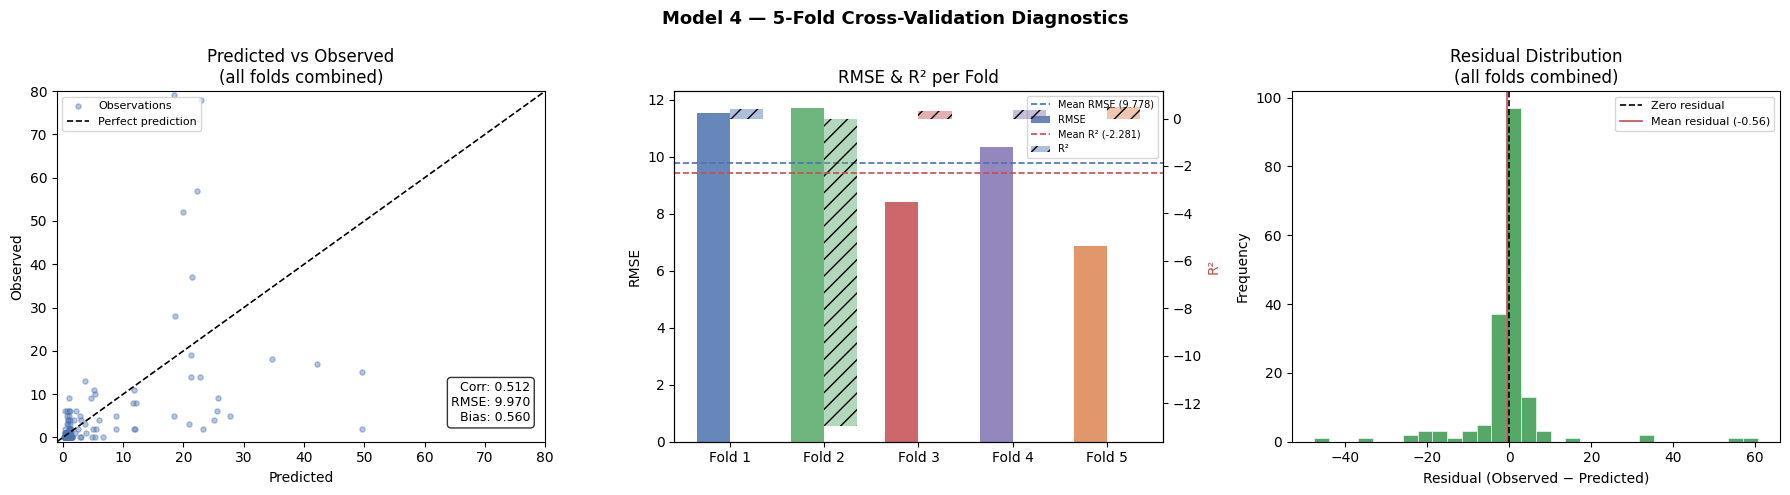

In [ ]:

# ── CV Visualisation ──────────────────────────────────────────────────────────
fold_labels = [f"Fold {i+1}" for i in range(len(cv_results))]
fold_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#DD8452"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Predicted vs Observed (all folds combined)
ax = axes[0]
ax.scatter(all_preds, all_obs, alpha=0.4, s=14, color="#4C72B0", label="Observations")
lims = [min(all_preds.min(), all_obs.min()) - 1,
        max(all_preds.max(), all_obs.max()) + 1]
ax.plot(lims, lims, "k--", linewidth=1.2, label="Perfect prediction")
overall_corr = np.corrcoef(all_preds, all_obs)[0, 1]
overall_rmse = np.sqrt(np.mean((all_obs - all_preds) ** 2))
overall_bias = np.mean(all_preds - all_obs)
ax.text(0.97, 0.05,
        f"Corr: {overall_corr:.3f}\nRMSE: {overall_rmse:.3f}\nBias: {overall_bias:.3f}",
        transform=ax.transAxes, fontsize=9, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
ax.set_xlabel("Predicted"); ax.set_ylabel("Observed")
ax.set_title("Predicted vs Observed\n(all folds combined)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(fontsize=8)

# Panel 2: RMSE and R² per fold
ax = axes[1]
x     = np.arange(len(fold_labels))
width = 0.35
ax.bar(x - width/2, cv_results[:, 0], width, color=fold_colors, alpha=0.85, label="RMSE")
ax.axhline(cv_results[:, 0].mean(), color="#4C72B0", linestyle="--", linewidth=1.2,
           label=f"Mean RMSE ({cv_results[:,0].mean():.3f})")
ax2_twin = ax.twinx()
ax2_twin.bar(x + width/2, cv_results[:, 1], width, color=fold_colors, alpha=0.45,
             hatch="//", label="R²")
ax2_twin.axhline(cv_results[:, 1].mean(), color="#C44E52", linestyle="--", linewidth=1.2,
                 label=f"Mean R² ({cv_results[:,1].mean():.3f})")
ax2_twin.set_ylabel("R²", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(fold_labels)
ax.set_ylabel("RMSE"); ax.set_title("RMSE & R² per Fold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right")

# Panel 3: Residuals distribution
ax = axes[2]
residuals = all_obs - all_preds
ax.hist(residuals, bins=30, color="#55A868", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2, label="Zero residual")
ax.axvline(residuals.mean(), color="#C44E52", linestyle="-", linewidth=1.2,
           label=f"Mean residual ({residuals.mean():.2f})")
ax.set_xlabel("Residual (Observed − Predicted)")
ax.set_ylabel("Frequency")
ax.set_title("Residual Distribution\n(all folds combined)")
ax.legend(fontsize=8)

fig.suptitle("Model 4 — 5-Fold Cross-Validation Diagnostics",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:


# ── Refit on full data for coefficient inspection and downstream use ───────────
X_full  = sm.add_constant(X_scaled)
model_4 = ZeroInflatedNegativeBinomialP(y, X_full).fit(
    method='bfgs', maxiter=1000, disp=False
)

null_model  = sm.GLM(y, np.ones((len(y), 1)), family=sm.families.Poisson()).fit()
mcfadden_r2 = 1 - (model_4.llf / null_model.llf)

print(f"\nFull-data refit — {len(y)} obs, {len(model_4.params)} parameters")
print(f"AIC: {model_4.aic:.4f}  |  BIC: {model_4.bic:.4f}  |  McFadden R²: {mcfadden_r2:.4f}")

print(f"\n{'─'*65}")
print(f"  {'Parameter':<40} {'Coef':>8}  {'IRR':>8}  {'p-value':>8}")
print(f"{'─'*65}")
for param, coef, pval in zip(model_4.params.index, model_4.params.values, model_4.pvalues.values):
    sig = "***" if pval<.001 else "**" if pval<.01 else "*" if pval<.05 else "." if pval<.10 else ""
    print(f"  {param:<40} {coef:>8.4f}  {np.exp(coef):>8.4f}  {pval:>8.4f} {sig}")
print(f"{'─'*65}")
print("Signif. codes: *** p<.001  ** p<.01  * p<.05  . p<.10")


Full-data refit — 174 obs, 9 parameters
AIC: 616.0946  |  BIC: 644.5261  |  McFadden R²: 0.7536

─────────────────────────────────────────────────────────────────
  Parameter                                    Coef       IRR   p-value
─────────────────────────────────────────────────────────────────
  inflate_const                            -17.3129    0.0000    0.9891 
  const                                      0.3064    1.3585    0.0083 **
  Military expenditure (% of GDP)            0.0786    1.0818    0.5392 
  High court independence                   -0.2533    0.7762    0.1733 
  Number below 60% of median                 1.1897    3.2861    0.0000 ***
  Government attacks on judiciary            0.2835    1.3278    0.0623 .
  weighted_populism                          0.4087    1.5048    0.0027 **
  Power distributed by gender                0.1756    1.1919    0.2701 
  alpha                                      1.1747    3.2371    0.0000 ***
──────────────────────────────

In [ ]:
# ── Store CV summary for model comparison ─────────────────────────────────────
cv_summary["Model 4 (+Gender)"] = {
    "RMSE": (cv_results[:,0].mean(), cv_results[:,0].std()),
    "R²":   (cv_results[:,1].mean(), cv_results[:,1].std()),
    "Corr": (cv_results[:,2].mean(), cv_results[:,2].std()),
    "Bias": (cv_results[:,3].mean(), cv_results[:,3].std()),
}

## Comparision to model 2

In [ ]:
models = {
    "Model 2 (+ Populism)":       model_2,
    "Model 4 (+ Gender)":         model_4,
}

print("=" * 75)
print("COEFFICIENT SUMMARY (count-model params only, IRR = exp(coef))")
print("=" * 75)

for name, mdl in models.items():
    params     = mdl.params
    pvals      = mdl.pvalues
    conf       = mdl.conf_int()
    irr        = np.exp(params)
    count_mask = ~params.index.str.startswith("inflate_")

    df_coef = pd.DataFrame({
        "coef":    params[count_mask],
        "IRR":     irr[count_mask],
        "CI_low":  np.exp(conf.loc[count_mask, 0]),
        "CI_high": np.exp(conf.loc[count_mask, 1]),
        "p-value": pvals[count_mask],
        "sig":     pvals[count_mask].apply(
                       lambda p: "***" if p < .001 else
                                 "**"  if p < .01  else
                                 "*"   if p < .05  else
                                 "."   if p < .10  else "")
    })
    print(f"\n{name}")
    print("-" * 75)
    print(df_coef.to_string(float_format=lambda x: f"{x:8.4f}"))
    print("Signif. codes: *** p<.001  ** p<.01  * p<.05  . p<.10")


COEFFICIENT SUMMARY (count-model params only, IRR = exp(coef))

Model 2 (+ Populism)
---------------------------------------------------------------------------
                                    coef      IRR   CI_low  CI_high  p-value  sig
const                             0.3155   1.3710   1.0928   1.7199   0.0064   **
Military expenditure (% of GDP)   0.1007   1.1059   0.8618   1.4191   0.4289     
High court independence          -0.1802   0.8351   0.5932   1.1755   0.3016     
Number below 60% of median        1.2071   3.3437   2.7381   4.0831   0.0000  ***
Government attacks on judiciary   0.3281   1.3883   1.0430   1.8478   0.0245    *
weighted_populism                 0.4091   1.5055   1.1538   1.9644   0.0026   **
alpha                             1.1833   3.2652   2.0728   5.1437   0.0000  ***
Signif. codes: *** p<.001  ** p<.01  * p<.05  . p<.10

Model 4 (+ Gender)
---------------------------------------------------------------------------
                                 

In [ ]:


# Draws directly from cv_summary populated during each model's training cell
print("\n" + "=" * 75)
print("CROSS-VALIDATION FIT METRICS (5-fold, mean ± SD)")
print("=" * 75)

cv_metrics_df = pd.DataFrame({
    name: {
        "RMSE":  f"{vals['RMSE'][0]:.4f} ± {vals['RMSE'][1]:.4f}",
        "R²":    f"{vals['R²'][0]:.4f} ± {vals['R²'][1]:.4f}",
        "Corr":  f"{vals['Corr'][0]:.4f} ± {vals['Corr'][1]:.4f}",
        "Bias":  f"{vals['Bias'][0]:.4f} ± {vals['Bias'][1]:.4f}",
    }
    for name, vals in cv_summary.items()
    if name in ["Model 2 (+Populism)", "Model 4 (+Gender)"]
}).T

print(cv_metrics_df.to_string())
print("\nNote: Metrics are averaged across 5 folds; SD reflects fold-to-fold stability.")

# Also print AIC / BIC / LogLik from full-data refits
print("\n" + "=" * 75)
print("INFORMATION CRITERIA (full-data refit)")
print("=" * 75)
ic_df = pd.DataFrame({
    name: {"AIC": f"{mdl.aic:.4f}", "BIC": f"{mdl.bic:.4f}", "LogLik": f"{mdl.llf:.4f}",
           "N params": len(mdl.params)}
    for name, mdl in models.items()
}).T
print(ic_df.to_string())
print("\nNote: Lower AIC/BIC = better fit penalised for complexity.")



CROSS-VALIDATION FIT METRICS (5-fold, mean ± SD)
                                RMSE                R²             Corr             Bias
Model 2 (+Populism)  9.4875 ± 1.6914  -1.8907 ± 4.5947  0.6734 ± 0.0343  0.4618 ± 2.0244
Model 4 (+Gender)    9.7777 ± 1.8699  -2.2811 ± 5.3370  0.6567 ± 0.0232  0.5569 ± 2.0495

Note: Metrics are averaged across 5 folds; SD reflects fold-to-fold stability.

INFORMATION CRITERIA (full-data refit)
                           AIC       BIC     LogLik N params
Model 2 (+ Populism)  615.3141  640.5866  -299.6571        8
Model 4 (+ Gender)    616.0946  644.5261  -299.0473        9

Note: Lower AIC/BIC = better fit penalised for complexity.


In [ ]:
def lrt(mdl_restricted, mdl_full, df_diff):
    lr_stat = 2 * (mdl_full.llf - mdl_restricted.llf)
    p_val   = chi2.sf(lr_stat, df_diff)
    return lr_stat, p_val

lr23, p23 = lrt(model_2, model_3, df_diff=1)   # M2 → M3: does RSF interaction add value?
lr24, p24 = lrt(model_2, model_4, df_diff=1)   # M2 → M4: does gender add value?
lr34, p34 = lrt(model_3, model_4, df_diff=1)   # M3 → M4: gender vs RSF interaction

print("\n" + "=" * 75)
print("LIKELIHOOD-RATIO TESTS (nested comparisons)")
print("=" * 75)
lrt_df = pd.DataFrame({
    "Comparison":   ["M2 vs M3 (+Pop×RSF)",
                     "M2 vs M4 (+Gender)",
                     "M3 vs M4 (Gender vs RSF interaction)"],
    "LR statistic": [lr23, lr24, lr34],
    "df":           [1, 1, 1],
    "p-value":      [p23, p24, p34],
    "sig":          ["***" if p < .001 else "**" if p < .01 else
                     "*"   if p < .05  else "n.s."
                     for p in [p23, p24, p34]]
})
print(lrt_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


LIKELIHOOD-RATIO TESTS (nested comparisons)
                          Comparison  LR statistic  df  p-value  sig
                 M2 vs M3 (+Pop×RSF)       -3.3843   1   1.0000 n.s.
                  M2 vs M4 (+Gender)        1.2195   1   0.2694 n.s.
M3 vs M4 (Gender vs RSF interaction)        4.6038   1   0.0319    *


# Model 5: Populism x Disaggregated Gender
Two parallel ZINB models using Model 2 predictors (Populism), one for male journalist victims and one for female.

In [ ]:
cy.dropna(inplace=True)

X_m2_features = ["Military expenditure (% of GDP)",
                 "High court independence",
                 "Number below 60% of median",
                 "Government attacks on judiciary",
                 "weighted_populism"]

scaler = StandardScaler()

# ── 5a: Male journalist victims ──────────────────────────────────────────
X5 = cy[X_m2_features]
y5a = cy["physical_incidents_male"]

X5s = pd.DataFrame(scaler.fit_transform(X5), columns=X5.columns, index=X5.index)
X5_train, X5_test, y5a_train, y5a_test = train_test_split(
    X5s, y5a, test_size=0.30, random_state=42
)
X5_train_c = sm.add_constant(X5_train)
X5_test_c  = sm.add_constant(X5_test)

model_5a = ZeroInflatedNegativeBinomialP(y5a_train, X5_train_c).fit(
    method='bfgs', maxiter=1000, disp=False
)
print('Model 5a (Male): trained on', len(y5a_train), 'obs')

# ── 5b: Female journalist victims ────────────────────────────────────────
y5b = cy["physical_incidents_female"]

_, _, y5b_train, y5b_test = train_test_split(
    X5s, y5b, test_size=0.30, random_state=42
)

model_5b = ZeroInflatedNegativeBinomialP(y5b_train, X5_train_c).fit(
    method='bfgs', maxiter=1000, disp=False
)
print('Model 5b (Female): trained on', len(y5b_train), 'obs')


Model 5a (Male): trained on 121 obs
Model 5b (Female): trained on 121 obs


## Coefficient comparison: Male vs Female

In [ ]:
# ── Coefficient table: Model 5a vs 5b ───────────────────────────────────
print('=' * 75)
print('COEFFICIENT SUMMARY — Male (5a) vs Female (5b)')
print('IRR = exp(coef) | count-model params only')
print('=' * 75)

for label, mdl in [('Model 5a  Male victims', model_5a),
                   ('Model 5b  Female victims', model_5b)]:
    params = mdl.params
    pvals  = mdl.pvalues
    conf   = mdl.conf_int()
    irr    = np.exp(params)
    count_mask = ~params.index.str.startswith('inflate_')

    df_coef = pd.DataFrame({
        'coef':    params[count_mask],
        'IRR':     irr[count_mask],
        'CI_low':  np.exp(conf.loc[count_mask, 0]),
        'CI_high': np.exp(conf.loc[count_mask, 1]),
        'p-value': pvals[count_mask],
        'sig':     pvals[count_mask].apply(
                       lambda p: '***' if p < .001 else
                                 '**'  if p < .01  else
                                 '*'   if p < .05  else 'n.s.')
    })
    print(f'\n{label}')
    print(df_coef.to_string(float_format=lambda x: f'{x:.4f}'))


COEFFICIENT SUMMARY — Male (5a) vs Female (5b)
IRR = exp(coef) | count-model params only

Model 5a  Male victims
                                   coef    IRR  CI_low  CI_high  p-value   sig
const                            0.1547 1.1673  0.8750   1.5573   0.2929  n.s.
Military expenditure (% of GDP)  0.0953 1.1000  0.8129   1.4884   0.5368  n.s.
High court independence         -0.2474 0.7809  0.5057   1.2056   0.2643  n.s.
Number below 60% of median       1.1285 3.0910  2.4263   3.9378   0.0000   ***
Government attacks on judiciary  0.5673 1.7636  1.1551   2.6925   0.0086    **
weighted_populism                0.4843 1.6230  1.1527   2.2851   0.0055    **
alpha                            1.2708 3.5638  1.9199   6.6149   0.0001   ***

Model 5b  Female victims
                                   coef    IRR  CI_low  CI_high  p-value   sig
const                           -1.4095 0.2443  0.1553   0.3841   0.0000   ***
Military expenditure (% of GDP) -0.1900 0.8270  0.5642   1.2122   0.330

In [ ]:
cy["physical_incidents_male"].sum()

np.int64(617)

In [ ]:
cy["physical_incidents_female"].sum()

np.int64(148)

## Fit metrics and likelihood-ratio tests

In [ ]:
yp5a = model_5a.predict(X5_test_c)
yp5b = model_5b.predict(X5_test_c)

def fit_metrics(y_true, y_pred, mdl):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_pred, y_true)[0, 1]
    bias = np.mean(y_pred - y_true.values)
    null_ll = -len(y_true) * np.log(y_true.mean()) if y_true.mean() > 0 else np.nan
    mcf_r2  = 1 - mdl.llf / null_ll if not np.isnan(null_ll) else np.nan
    return dict(RMSE=rmse, R2=r2, Corr=corr, Bias=bias,
                AIC=mdl.aic, BIC=mdl.bic, McFadden_R2=mcf_r2)

m5a_stats = fit_metrics(y5a_test, yp5a, model_5a)
m5b_stats = fit_metrics(y5b_test, yp5b, model_5b)

metrics_df = pd.DataFrame([m5a_stats, m5b_stats],
                          index=['5a  Male', '5b  Female'])
print('\nFIT METRICS')
print(metrics_df.to_string(float_format=lambda x: f'{x:.4f}'))

# LRT: compare each gender model vs model_3 (same predictors, total outcome)
def lrt(mdl_r, mdl_f, df_diff):
    lr_stat = 2 * (mdl_f.llf - mdl_r.llf)
    p_val   = chi2.sf(lr_stat, df_diff)
    return lr_stat, p_val


FIT METRICS
             RMSE     R2   Corr    Bias      AIC      BIC  McFadden_R2
5a  Male   7.8340 0.4172 0.6540 -0.6218 415.6803 438.0467      -1.8944
5b  Female 1.7784 0.3226 0.5868 -0.0423 208.2390 230.6054      10.7450
